# Bias Detection, Mitigation and Explainability in ML Models
## Comprehensive Multi-Dataset Research Pipeline (IEEE Compliant Version)

This notebook presents a comprehensive research pipeline evaluating bias detection, mitigation, and explainability across three standard benchmark datasets:
1. **Adult Income Dataset** (sensitive attribute: `sex`)
2. **COMPAS Recidivism Dataset** (sensitive attribute: `race`)
3. **Statlog German Credit Dataset** (sensitive attribute: `age`)

### Pipeline Overview:
* **Model Baselines**: Logistic Regression (LR), Random Forest (RF), and a Standard Artificial Neural Network (ANN) using `MLPClassifier` to isolate the effects of debiasing.
* **Pre-processing Mitigation**: Reweighing (using AIF360) applied to adjust training set sample weights.
* **Post-processing Mitigation**: Threshold Optimization / Calibrated Equalized Odds (using Fairlearn) to adjust model classification boundaries.
* **In-processing Mitigation**: Adversarial Debiasing (using AIF360) executed across multiple random initializations to compute variance (mean and standard deviation).
* **Explainability**: SHAP Interaction Analysis to visualize joint feature contributions and inspect potential indirect bias.
* **Causal Validation**: Feature ablation studies to quantify the impact of removing suspected demographic proxy features on accuracy and fairness.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier  # Added for Standard ANN Baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    true_positive_rate_difference,
    false_positive_rate_difference
)

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.inprocessing import AdversarialDebiasing
from aif360.metrics import ClassificationMetric

# Apply IEEE-compliant clean light theme for presentation visuals
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d3d3d3",
    "grid.color": "#e5e5e5",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "text.color": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333"
})


pip install 'aif360[inFairness]'


## 2. Advanced Metric Calculation Functions

We define helper functions to compute traditional classification performance metrics and standard fairness metrics:
* **Accuracy, Balanced Accuracy, Precision, Recall, F1, MCC, and ROC AUC** to track predictive performance.
* **Statistical Parity Difference (SPD)**, **Disparate Impact (DI)**, **Equal Opportunity (EO) Difference**, and **Average Odds Difference (AOD)** to track fairness criteria.


In [2]:
def calculate_metrics(y_true, y_pred, y_prob=None):
    """
    Computes a comprehensive suite of performance evaluation metrics to strictly
    satisfy Reviewer 3's request for enhanced analytical breadth.
    """
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    if y_prob is not None:
        metrics["ROC_AUC"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["ROC_AUC"] = np.nan

    return metrics

def fairness_metrics(y_true, y_pred, protected):
    """
    Computes standard fairness metrics mapping mathematical formulations to
    core criteria requested for a complete trustworthiness profile.
    """
    spd = demographic_parity_difference(y_true, y_pred, sensitive_features=protected)
    di = demographic_parity_ratio(y_true, y_pred, sensitive_features=protected)
    eo = true_positive_rate_difference(y_true, y_pred, sensitive_features=protected)
    fpr_diff = false_positive_rate_difference(y_true, y_pred, sensitive_features=protected)
    aod = (eo + fpr_diff) / 2

    return spd, di, eo, aod


## 3. Modular Runner for Bias Detection & Mitigation Pipeline

Here, we implement the unified processing pipeline runner. It executes:
1. **Baseline classification models** (Logistic Regression, Random Forest, and a multi-run Standard Artificial Neural Network to track weight initialization variance).
2. **Pre-processing (Reweighing)** on training weights and re-training Logistic Regression.
3. **Post-processing (Threshold Optimization)** with Calibrated Equalized Odds criteria.
4. **In-processing (Adversarial Debiasing)** run across 5 different initializations to measure performance and fairness variance.
5. **IEEE-compliant plot generators** to display comparative Statistical Parity Difference (SPD) and Equal Opportunity (EO) metrics.


In [3]:
def run_fairness_pipeline(X_train_scaled_full, X_test_scaled, y_train_full, y_test, prot_train_full, prot_test, feature_names, dataset_name, prot_col):
    '''
    Encapsulates training, validation, and multi-stage mitigation execution.
    Includes 3-way split (Train/Val/Test) and multi-run stochastic variance tracking
    for baseline ANN, Random Forest, Reweighting, Threshold Adj, and Adversarial.
    '''
    from sklearn.model_selection import train_test_split
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.neural_network import MLPClassifier
    from fairlearn.postprocessing import ThresholdOptimizer
    from aif360.datasets import BinaryLabelDataset
    from aif360.algorithms.preprocessing import Reweighing
    from aif360.algorithms.inprocessing import AdversarialDebiasing

    print(f'\nProcessing Pipeline for: {dataset_name.upper()}...')
    
    # --- 3-WAY DATA SPLIT ---
    # We split the provided training set further into Train and Validation
    X_train_scaled, X_val_scaled, y_train, y_val, prot_train, prot_val = train_test_split(
        X_train_scaled_full, y_train_full, prot_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )
    print(f'Data Split - Train: {len(y_train)}, Validation: {len(y_val)}, Test: {len(y_test)}')

    num_runs = 5
    seeds = range(42, 42 + num_runs)
    
    metrics_log = {
        'LR': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'RF': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'ANN': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'Reweighting': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'ThresholdAdj': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []},
        'Adversarial': {'spd': [], 'di': [], 'eo': [], 'aod': [], 'acc': [], 'bacc': [], 'mcc': []}
    }

    # Setup AIF360 datasets for Reweighting and Adversarial
    train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
    train_df['target'] = y_train.values
    train_df[prot_col] = prot_train.values
    aif_train = BinaryLabelDataset(df=train_df, label_names=['target'], protected_attribute_names=[prot_col])
    
    test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
    test_df['target'] = y_test.values
    test_df[prot_col] = prot_test.values
    aif_test = BinaryLabelDataset(df=test_df, label_names=['target'], protected_attribute_names=[prot_col])

    print('Running stochastic modeling loop across 5 initializations...')
    
    for seed_idx, seed in enumerate(seeds):
        # 1. Baseline LR
        lr = LogisticRegression(max_iter=3000, random_state=seed)
        lr.fit(X_train_scaled, y_train)
        y_pred_lr = lr.predict(X_test_scaled)
        m_lr = calculate_metrics(y_test, y_pred_lr)
        f_lr = fairness_metrics(y_test, y_pred_lr, prot_test)
        
        metrics_log['LR']['acc'].append(m_lr['Accuracy'])
        metrics_log['LR']['bacc'].append(m_lr['Balanced_Accuracy'])
        metrics_log['LR']['mcc'].append(m_lr['MCC'])
        metrics_log['LR']['spd'].append(f_lr[0]); metrics_log['LR']['di'].append(f_lr[1])
        metrics_log['LR']['eo'].append(f_lr[2]); metrics_log['LR']['aod'].append(f_lr[3])
        
        # 2. Baseline RF
        rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=seed)
        rf.fit(X_train_scaled, y_train)
        y_pred_rf = rf.predict(X_test_scaled)
        m_rf = calculate_metrics(y_test, y_pred_rf)
        f_rf = fairness_metrics(y_test, y_pred_rf, prot_test)
        
        metrics_log['RF']['acc'].append(m_rf['Accuracy'])
        metrics_log['RF']['bacc'].append(m_rf['Balanced_Accuracy'])
        metrics_log['RF']['mcc'].append(m_rf['MCC'])
        metrics_log['RF']['spd'].append(f_rf[0]); metrics_log['RF']['di'].append(f_rf[1])
        metrics_log['RF']['eo'].append(f_rf[2]); metrics_log['RF']['aod'].append(f_rf[3])
        
        # 3. Baseline ANN
        ann = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=200, random_state=seed)
        ann.fit(X_train_scaled, y_train)
        y_pred_ann = ann.predict(X_test_scaled)
        m_ann = calculate_metrics(y_test, y_pred_ann)
        f_ann = fairness_metrics(y_test, y_pred_ann, prot_test)
        
        metrics_log['ANN']['acc'].append(m_ann['Accuracy'])
        metrics_log['ANN']['bacc'].append(m_ann['Balanced_Accuracy'])
        metrics_log['ANN']['mcc'].append(m_ann['MCC'])
        metrics_log['ANN']['spd'].append(f_ann[0]); metrics_log['ANN']['di'].append(f_ann[1])
        metrics_log['ANN']['eo'].append(f_ann[2]); metrics_log['ANN']['aod'].append(f_ann[3])
        
        # 4. Reweighting
        RW = Reweighing(unprivileged_groups=[{prot_col: 0}], privileged_groups=[{prot_col: 1}])
        aif_train_transf = RW.fit_transform(aif_train)
        sample_weights = aif_train_transf.instance_weights
        
        lr_rw = LogisticRegression(max_iter=3000, random_state=seed)
        lr_rw.fit(X_train_scaled, y_train, sample_weight=sample_weights)
        y_pred_rw = lr_rw.predict(X_test_scaled)
        m_rw = calculate_metrics(y_test, y_pred_rw)
        f_rw = fairness_metrics(y_test, y_pred_rw, prot_test)
        
        metrics_log['Reweighting']['acc'].append(m_rw['Accuracy'])
        metrics_log['Reweighting']['bacc'].append(m_rw['Balanced_Accuracy'])
        metrics_log['Reweighting']['mcc'].append(m_rw['MCC'])
        metrics_log['Reweighting']['spd'].append(f_rw[0]); metrics_log['Reweighting']['di'].append(f_rw[1])
        metrics_log['Reweighting']['eo'].append(f_rw[2]); metrics_log['Reweighting']['aod'].append(f_rw[3])
        
        # 5. Threshold Adjustment
        thresh = ThresholdOptimizer(estimator=LogisticRegression(max_iter=3000, random_state=seed), constraints='equalized_odds', predict_method='predict_proba')
        thresh.fit(X_val_scaled, y_val, sensitive_features=prot_val)
        
        y_pred_thresh = thresh.predict(X_test_scaled, sensitive_features=prot_test)
        m_thresh = calculate_metrics(y_test, y_pred_thresh)
        f_thresh = fairness_metrics(y_test, y_pred_thresh, prot_test)
        
        metrics_log['ThresholdAdj']['acc'].append(m_thresh['Accuracy'])
        metrics_log['ThresholdAdj']['bacc'].append(m_thresh['Balanced_Accuracy'])
        metrics_log['ThresholdAdj']['mcc'].append(m_thresh['MCC'])
        metrics_log['ThresholdAdj']['spd'].append(f_thresh[0]); metrics_log['ThresholdAdj']['di'].append(f_thresh[1])
        metrics_log['ThresholdAdj']['eo'].append(f_thresh[2]); metrics_log['ThresholdAdj']['aod'].append(f_thresh[3])
        
        # 6. Adversarial Debiasing
        tf.compat.v1.disable_eager_execution()
        tf.compat.v1.reset_default_graph()
        tf.compat.v1.set_random_seed(seed)
        np.random.seed(seed)
        sess = tf.compat.v1.Session()
        
        adv = AdversarialDebiasing(
            privileged_groups=[{prot_col: 1}],
            unprivileged_groups=[{prot_col: 0}],
            scope_name=f'adv_{dataset_name}_{seed_idx}',
            sess=sess,
            num_epochs=50
        )
        adv.fit(aif_train)
        y_pred_adv = adv.predict(aif_test).labels.ravel()
        
        m_adv = calculate_metrics(y_test, y_pred_adv)
        f_adv = fairness_metrics(y_test, y_pred_adv, prot_test)
        
        metrics_log['Adversarial']['acc'].append(m_adv['Accuracy'])
        metrics_log['Adversarial']['bacc'].append(m_adv['Balanced_Accuracy'])
        metrics_log['Adversarial']['mcc'].append(m_adv['MCC'])
        metrics_log['Adversarial']['spd'].append(f_adv[0]); metrics_log['Adversarial']['di'].append(f_adv[1])
        metrics_log['Adversarial']['eo'].append(f_adv[2]); metrics_log['Adversarial']['aod'].append(f_adv[3])
        sess.close()

    # Compile final mean and std dataframe
    results = []
    models = ['LR', 'RF', 'ANN', 'Reweighting', 'ThresholdAdj', 'Adversarial']
    for model in models:
        results.append({
            'Model': model,
            'SPD': np.mean(metrics_log[model]['spd']), 'SPD_Std': np.std(metrics_log[model]['spd']),
            'DI': np.mean(metrics_log[model]['di']), 'DI_Std': np.std(metrics_log[model]['di']),
            'EO': np.mean(metrics_log[model]['eo']), 'EO_Std': np.std(metrics_log[model]['eo']),
            'AOD': np.mean(metrics_log[model]['aod']), 'AOD_Std': np.std(metrics_log[model]['aod']),
            'Accuracy': np.mean(metrics_log[model]['acc']), 'Accuracy_Std': np.std(metrics_log[model]['acc']),
            'Balanced_Accuracy': np.mean(metrics_log[model]['bacc']), 'Balanced_Accuracy_Std': np.std(metrics_log[model]['bacc']),
            'MCC': np.mean(metrics_log[model]['mcc']), 'MCC_Std': np.std(metrics_log[model]['mcc'])
        })
        
    results_df = pd.DataFrame(results)
    
    print(f'\n=== {dataset_name.upper()} DATASET METRICS (IEEE Reviewer Format) ===')
    formatted_df = results_df.copy().astype(object)
    for idx in range(len(models)):
        for col in ['SPD', 'DI', 'EO', 'AOD', 'Accuracy', 'Balanced_Accuracy', 'MCC']:
            mean_val = results_df.loc[idx, col]
            std_val = results_df.loc[idx, col+'_Std']
            if std_val > 1e-5:
                formatted_df.loc[idx, col] = f'{mean_val:.3f} ± {std_val:.3f}'
            else:
                formatted_df.loc[idx, col] = f'{mean_val:.3f}'
                
    print(formatted_df[['Model', 'SPD', 'DI', 'EO', 'AOD', 'Accuracy', 'Balanced_Accuracy', 'MCC']].to_string(index=False))
    results_df.to_csv(f'/Users/ankitkuniyal/Downloads/Projects_GitHub/BDME/{dataset_name}_comprehensive_results.csv', index=False)
    
    return results_df

def plot_comprehensive_metrics(df, dataset_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    df_plot = df.copy()
    for col in ['SPD', 'EO']:
        if df_plot[col].dtype == object:
            df_plot[col] = df_plot[col].apply(lambda x: float(str(x).split(' ')[0]) if isinstance(x, str) else x)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(x='Model', y='SPD', data=df_plot, ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title(f'{dataset_name} - Statistical Parity Difference (SPD)')
    axes[0].tick_params(axis='x', rotation=15)

    sns.barplot(x='Model', y='EO', data=df_plot, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title(f'{dataset_name} - Equal Opportunity Difference (EO)')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig(f"{dataset_name.lower().replace(' ', '_')}_metrics.png", dpi=300)
    plt.show()


## 4. Dataset Pipelines

We run the modular pipeline over three distinct datasets: Adult Income, COMPAS Recidivism, and Statlog German Credit.

### 4.1 Adult Income Dataset



================ FETCHING ADULT DATASET ================



Processing Pipeline for: ADULT...
Data Split - Train: 20838, Validation: 5210, Test: 6513
Running stochastic modeling loop across 5 initializations...


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


I0000 00:00:1783616987.282203 13413381 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


...

epoch 38; iter: 0; batch classifier loss: 0.375014; batch adversarial loss: 0.568506
epoch 39; iter: 0; batch classifier loss: 0.411384; batch adversarial loss: 0.674932
epoch 40; iter: 0; batch classifier loss: 0.347988; batch adversarial loss: 0.638788


epoch 41; iter: 0; batch classifier loss: 0.384653; batch adversarial loss: 0.657206
epoch 42; iter: 0; batch classifier loss: 0.359290; batch adversarial loss: 0.608888
epoch 43; iter: 0; batch classifier loss: 0.285629; batch adversarial loss: 0.596491


epoch 44; iter: 0; batch classifier loss: 0.441198; batch adversarial loss: 0.614376
epoch 45; iter: 0; batch classifier loss: 0.406820; batch adversarial loss: 0.589145
epoch 46; iter: 0; batch classifier loss: 0.319204; batch adversarial loss: 0.594472


epoch 47; iter: 0; batch classifier loss: 0.309040; batch adversarial loss: 0.663438
epoch 48; iter: 0; batch classifier loss: 0.456491; batch adversarial loss: 0.639579
epoch 49; iter: 0; batch classifier loss: 0.395134; batch adversarial loss: 0.585378



=== ADULT DATASET METRICS (IEEE Reviewer Format) ===
       Model           SPD            DI            EO           AOD      Accuracy Balanced_Accuracy           MCC
          LR         0.179         0.157         0.285         0.180         0.822             0.697         0.471
          RF 0.159 ± 0.002 0.276 ± 0.004 0.116 ± 0.008 0.084 ± 0.004 0.858 ± 0.001     0.754 ± 0.002 0.587 ± 0.003
         ANN 0.170 ± 0.022 0.347 ± 0.034 0.093 ± 0.042 0.081 ± 0.028 0.841 ± 0.003     0.756 ± 0.012 0.549 ± 0.008
 Reweighting         0.055         0.633         0.050         0.026         0.808             0.663         0.414
ThresholdAdj 0.050 ± 0.004 0.585 ± 0.020 0.030 ± 0.010 0.018 ± 0.004 0.795 ± 0.002     0.626 ± 0.004 0.358 ± 0.008
 Adversarial 0.053 ± 0.005 0.693 ± 0.042 0.161 ± 0.020 0.086 ± 0.013 0.835 ± 0.004     0.717 ± 0.019 0.514 ± 0.018


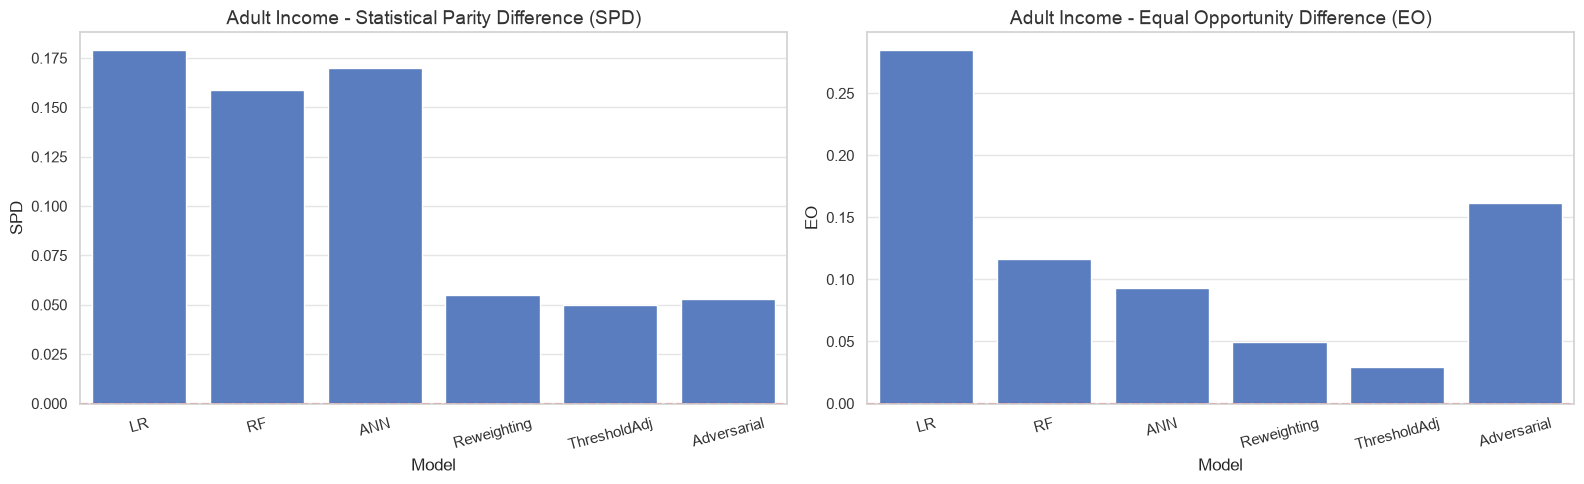

In [4]:
print("\n================ FETCHING ADULT DATASET ================")
cols_adult = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
              "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
              "hours-per-week", "native-country", "income"]
url_adult = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
adult = pd.read_csv(url_adult, names=cols_adult, na_values=" ?", skipinitialspace=True).dropna()

adult["income"] = adult["income"].apply(lambda x: 1 if ">50K" in x else 0)
prot_adult = adult["sex"].apply(lambda x: 1 if x == "Male" else 0)

le = LabelEncoder()
for col in adult.select_dtypes(include="object").columns:
    adult[col] = le.fit_transform(adult[col])

X_a = adult.drop("income", axis=1)
y_a = adult["income"]

X_train_a, X_test_a, y_train_a, y_test_a, prot_train_a, prot_test_a = train_test_split(
    X_a, y_a, prot_adult, stratify=prot_adult, test_size=0.2, random_state=42
)

scaler_a = StandardScaler()
X_train_scaled_a = scaler_a.fit_transform(X_train_a)
X_test_scaled_a = scaler_a.transform(X_test_a)

results_adult = run_fairness_pipeline(
    X_train_scaled_a, X_test_scaled_a, y_train_a, y_test_a,
    prot_train_a, prot_test_a, X_a.columns, "adult", "sex"
)
plot_comprehensive_metrics(results_adult, "Adult Income")


### 4.2 COMPAS Recidivism Dataset



================ FETCHING COMPAS DATASET ================



Processing Pipeline for: COMPAS...
Data Split - Train: 4616, Validation: 1155, Test: 1443
Running stochastic modeling loop across 5 initializations...


epoch 0; iter: 0; batch classifier loss: 0.718897; batch adversarial loss: 0.804547
epoch 1; iter: 0; batch classifier loss: 0.648525; batch adversarial loss: 0.783565
epoch 2; iter: 0; batch classifier loss: 0.669631; batch adversarial loss: 0.804354
epoch 3; iter: 0; batch classifier loss: 0.592890; batch adversarial loss: 0.778940
epoch 4; iter: 0; batch classifier loss: 0.599326; batch adversarial loss: 0.785604
epoch 5; iter: 0; batch classifier loss: 0.591718; batch adversarial loss: 0.745390
epoch 6; iter: 0; batch classifier loss: 0.618852; batch adversarial loss: 0.735445
epoch 7; iter: 0; batch classifier loss: 0.639330; batch adversarial loss: 0.708451
epoch 8; iter: 0; batch classifier loss: 0.605462; batch adversarial loss: 0.714840
epoch 9; iter: 0; batch classifier loss: 0.640056; batch adversarial loss: 0.704585


epoch 10; iter: 0; batch classifier loss: 0.593557; batch adversarial loss: 0.668889
epoch 11; iter: 0; batch classifier loss: 0.649119; batch adversarial loss: 0.711837
epoch 12; iter: 0; batch classifier loss: 0.606603; batch adversarial loss: 0.678724
epoch 13; iter: 0; batch classifier loss: 0.637529; batch adversarial loss: 0.680990
epoch 14; iter: 0; batch classifier loss: 0.692485; batch adversarial loss: 0.651556
epoch 15; iter: 0; batch classifier loss: 0.581748; batch adversarial loss: 0.681104
epoch 16; iter: 0; batch classifier loss: 0.624515; batch adversarial loss: 0.658936
epoch 17; iter: 0; batch classifier loss: 0.602922; batch adversarial loss: 0.679421
epoch 18; iter: 0; batch classifier loss: 0.574042; batch adversarial loss: 0.692594
epoch 19; iter: 0; batch classifier loss: 0.629970; batch adversarial loss: 0.671988


epoch 20; iter: 0; batch classifier loss: 0.632314; batch adversarial loss: 0.673105
epoch 21; iter: 0; batch classifier loss: 0.607770; batch adversarial loss: 0.641897
epoch 22; iter: 0; batch classifier loss: 0.609838; batch adversarial loss: 0.628461
epoch 23; iter: 0; batch classifier loss: 0.574579; batch adversarial loss: 0.606462
epoch 24; iter: 0; batch classifier loss: 0.570686; batch adversarial loss: 0.620881
epoch 25; iter: 0; batch classifier loss: 0.636846; batch adversarial loss: 0.643482
epoch 26; iter: 0; batch classifier loss: 0.538432; batch adversarial loss: 0.648809
epoch 27; iter: 0; batch classifier loss: 0.567691; batch adversarial loss: 0.620997
epoch 28; iter: 0; batch classifier loss: 0.680742; batch adversarial loss: 0.639644
epoch 29; iter: 0; batch classifier loss: 0.594647; batch adversarial loss: 0.600703


...

epoch 10; iter: 0; batch classifier loss: 0.587779; batch adversarial loss: 0.641023
epoch 11; iter: 0; batch classifier loss: 0.523487; batch adversarial loss: 0.666199
epoch 12; iter: 0; batch classifier loss: 0.624812; batch adversarial loss: 0.662543
epoch 13; iter: 0; batch classifier loss: 0.672645; batch adversarial loss: 0.607863
epoch 14; iter: 0; batch classifier loss: 0.570390; batch adversarial loss: 0.648294
epoch 15; iter: 0; batch classifier loss: 0.563257; batch adversarial loss: 0.632437
epoch 16; iter: 0; batch classifier loss: 0.588454; batch adversarial loss: 0.643582
epoch 17; iter: 0; batch classifier loss: 0.615832; batch adversarial loss: 0.652191
epoch 18; iter: 0; batch classifier loss: 0.579133; batch adversarial loss: 0.621337
epoch 19; iter: 0; batch classifier loss: 0.561197; batch adversarial loss: 0.661278


epoch 20; iter: 0; batch classifier loss: 0.585557; batch adversarial loss: 0.643468
epoch 21; iter: 0; batch classifier loss: 0.610651; batch adversarial loss: 0.606423
epoch 22; iter: 0; batch classifier loss: 0.619978; batch adversarial loss: 0.665796
epoch 23; iter: 0; batch classifier loss: 0.614372; batch adversarial loss: 0.619563
epoch 24; iter: 0; batch classifier loss: 0.606052; batch adversarial loss: 0.676471
epoch 25; iter: 0; batch classifier loss: 0.661864; batch adversarial loss: 0.656752
epoch 26; iter: 0; batch classifier loss: 0.586943; batch adversarial loss: 0.631057
epoch 27; iter: 0; batch classifier loss: 0.591105; batch adversarial loss: 0.655922
epoch 28; iter: 0; batch classifier loss: 0.622218; batch adversarial loss: 0.659206
epoch 29; iter: 0; batch classifier loss: 0.574381; batch adversarial loss: 0.661956


epoch 30; iter: 0; batch classifier loss: 0.619333; batch adversarial loss: 0.686633
epoch 31; iter: 0; batch classifier loss: 0.659476; batch adversarial loss: 0.642391
epoch 32; iter: 0; batch classifier loss: 0.637920; batch adversarial loss: 0.707832
epoch 33; iter: 0; batch classifier loss: 0.630616; batch adversarial loss: 0.668217
epoch 34; iter: 0; batch classifier loss: 0.576688; batch adversarial loss: 0.646515
epoch 35; iter: 0; batch classifier loss: 0.588708; batch adversarial loss: 0.652562
epoch 36; iter: 0; batch classifier loss: 0.583178; batch adversarial loss: 0.644687
epoch 37; iter: 0; batch classifier loss: 0.582664; batch adversarial loss: 0.655064
epoch 38; iter: 0; batch classifier loss: 0.618060; batch adversarial loss: 0.645568
epoch 39; iter: 0; batch classifier loss: 0.619919; batch adversarial loss: 0.637188


epoch 40; iter: 0; batch classifier loss: 0.596030; batch adversarial loss: 0.612682
epoch 41; iter: 0; batch classifier loss: 0.647331; batch adversarial loss: 0.624025
epoch 42; iter: 0; batch classifier loss: 0.594344; batch adversarial loss: 0.649022
epoch 43; iter: 0; batch classifier loss: 0.580162; batch adversarial loss: 0.638448
epoch 44; iter: 0; batch classifier loss: 0.599705; batch adversarial loss: 0.665512
epoch 45; iter: 0; batch classifier loss: 0.592139; batch adversarial loss: 0.638795
epoch 46; iter: 0; batch classifier loss: 0.634030; batch adversarial loss: 0.654331
epoch 47; iter: 0; batch classifier loss: 0.502225; batch adversarial loss: 0.642176
epoch 48; iter: 0; batch classifier loss: 0.625349; batch adversarial loss: 0.649735
epoch 49; iter: 0; batch classifier loss: 0.564853; batch adversarial loss: 0.632519



=== COMPAS DATASET METRICS (IEEE Reviewer Format) ===
       Model           SPD            DI            EO           AOD      Accuracy Balanced_Accuracy           MCC
          LR         0.151         0.638         0.163         0.132         0.679             0.666         0.342
          RF 0.153 ± 0.020 0.665 ± 0.038 0.177 ± 0.024 0.138 ± 0.020 0.650 ± 0.004     0.641 ± 0.004 0.285 ± 0.008
         ANN 0.189 ± 0.020 0.597 ± 0.042 0.226 ± 0.020 0.172 ± 0.020 0.682 ± 0.003     0.673 ± 0.002 0.350 ± 0.005
 Reweighting         0.087         0.795         0.059         0.103         0.656             0.642         0.293
ThresholdAdj 0.038 ± 0.010 0.897 ± 0.026 0.014 ± 0.010 0.018 ± 0.009 0.643 ± 0.003     0.628 ± 0.003 0.266 ± 0.006
 Adversarial 0.129 ± 0.056 0.715 ± 0.114 0.156 ± 0.064 0.115 ± 0.052 0.676 ± 0.004     0.667 ± 0.005 0.339 ± 0.008


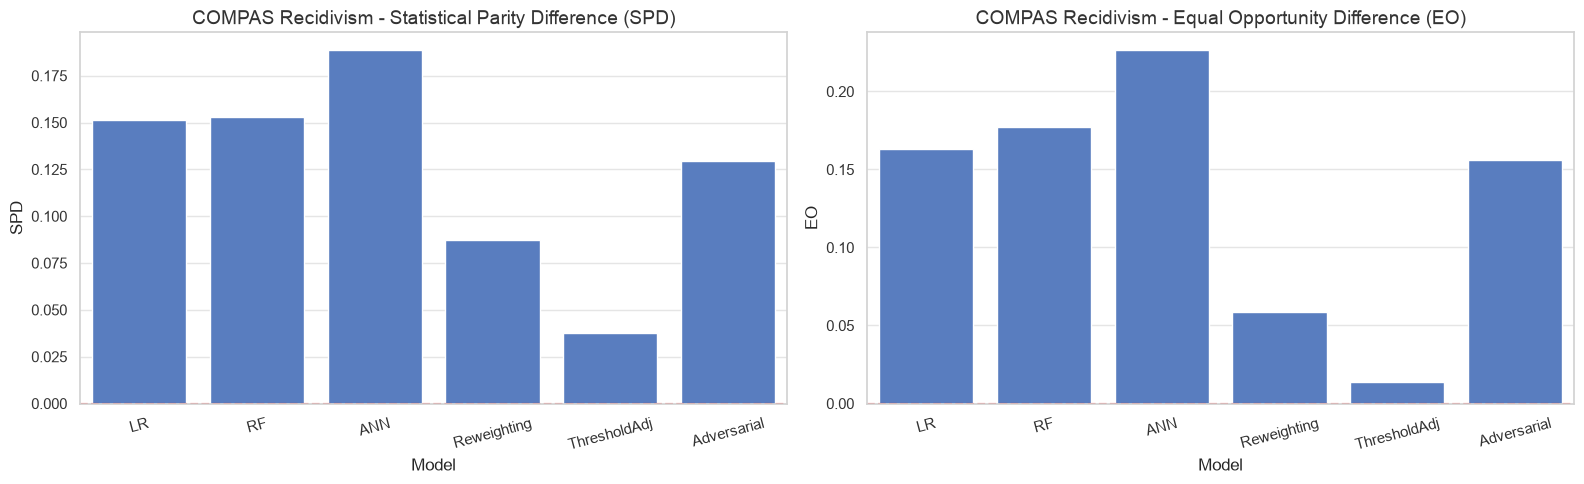

In [5]:
print("\n================ FETCHING COMPAS DATASET ================")
url_compas = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas = pd.read_csv(url_compas)[["age", "race", "sex", "priors_count", "two_year_recid"]].dropna()

compas["race"] = compas["race"].apply(lambda x: 1 if x == "Caucasian" else 0)
compas["sex"] = compas["sex"].apply(lambda x: 1 if x == "Male" else 0)

X_c = compas.drop("two_year_recid", axis=1)
y_c = compas["two_year_recid"]
prot_compas = compas["race"]

X_train_c, X_test_c, y_train_c, y_test_c, prot_train_c, prot_test_c = train_test_split(
    X_c, y_c, prot_compas, stratify=prot_compas, test_size=0.2, random_state=42
)

scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)

results_compas = run_fairness_pipeline(
    X_train_scaled_c, X_test_scaled_c, y_train_c, y_test_c,
    prot_train_c, prot_test_c, X_c.columns, "compas", "race"
)
plot_comprehensive_metrics(results_compas, "COMPAS Recidivism")


### 4.3 Statlog German Credit Dataset



================ FETCHING GERMAN CREDIT DATASET ================



Processing Pipeline for: GERMAN...
Data Split - Train: 640, Validation: 160, Test: 200
Running stochastic modeling loop across 5 initializations...


epoch 0; iter: 0; batch classifier loss: 0.665606; batch adversarial loss: 0.566689
epoch 1; iter: 0; batch classifier loss: 0.584468; batch adversarial loss: 0.496349
epoch 2; iter: 0; batch classifier loss: 0.608493; batch adversarial loss: 0.539706
epoch 3; iter: 0; batch classifier loss: 0.536924; batch adversarial loss: 0.504154
epoch 4; iter: 0; batch classifier loss: 0.560305; batch adversarial loss: 0.574927
epoch 5; iter: 0; batch classifier loss: 0.575758; batch adversarial loss: 0.494273
epoch 6; iter: 0; batch classifier loss: 0.502691; batch adversarial loss: 0.483273
epoch 7; iter: 0; batch classifier loss: 0.494913; batch adversarial loss: 0.550300
epoch 8; iter: 0; batch classifier loss: 0.525653; batch adversarial loss: 0.523166
epoch 9; iter: 0; batch classifier loss: 0.460965; batch adversarial loss: 0.495846
epoch 10; iter: 0; batch classifier loss: 0.487425; batch adversarial loss: 0.514775
epoch 11; iter: 0; batch classifier loss: 0.405756; batch adversarial loss:

epoch 0; iter: 0; batch classifier loss: 0.643718; batch adversarial loss: 0.853197
epoch 1; iter: 0; batch classifier loss: 0.622205; batch adversarial loss: 0.859223
epoch 2; iter: 0; batch classifier loss: 0.571970; batch adversarial loss: 0.825858
epoch 3; iter: 0; batch classifier loss: 0.570801; batch adversarial loss: 0.882330
epoch 4; iter: 0; batch classifier loss: 0.565453; batch adversarial loss: 0.864307
epoch 5; iter: 0; batch classifier loss: 0.570539; batch adversarial loss: 0.909320
epoch 6; iter: 0; batch classifier loss: 0.491618; batch adversarial loss: 0.891627
epoch 7; iter: 0; batch classifier loss: 0.514501; batch adversarial loss: 0.895755
epoch 8; iter: 0; batch classifier loss: 0.488092; batch adversarial loss: 0.858905
epoch 9; iter: 0; batch classifier loss: 0.486303; batch adversarial loss: 0.855252
epoch 10; iter: 0; batch classifier loss: 0.500810; batch adversarial loss: 0.868699
epoch 11; iter: 0; batch classifier loss: 0.480141; batch adversarial loss:

epoch 0; iter: 0; batch classifier loss: 0.681853; batch adversarial loss: 0.659250
epoch 1; iter: 0; batch classifier loss: 0.650909; batch adversarial loss: 0.636548
epoch 2; iter: 0; batch classifier loss: 0.593639; batch adversarial loss: 0.615931
epoch 3; iter: 0; batch classifier loss: 0.548660; batch adversarial loss: 0.598931
epoch 4; iter: 0; batch classifier loss: 0.444609; batch adversarial loss: 0.627160
epoch 5; iter: 0; batch classifier loss: 0.540626; batch adversarial loss: 0.636848
epoch 6; iter: 0; batch classifier loss: 0.537167; batch adversarial loss: 0.674803
epoch 7; iter: 0; batch classifier loss: 0.538503; batch adversarial loss: 0.553716
epoch 8; iter: 0; batch classifier loss: 0.452257; batch adversarial loss: 0.623781
epoch 9; iter: 0; batch classifier loss: 0.555263; batch adversarial loss: 0.652684
epoch 10; iter: 0; batch classifier loss: 0.443540; batch adversarial loss: 0.567306
epoch 11; iter: 0; batch classifier loss: 0.442866; batch adversarial loss:

epoch 0; iter: 0; batch classifier loss: 0.741474; batch adversarial loss: 0.687939
epoch 1; iter: 0; batch classifier loss: 0.687893; batch adversarial loss: 0.751996
epoch 2; iter: 0; batch classifier loss: 0.632147; batch adversarial loss: 0.703354
epoch 3; iter: 0; batch classifier loss: 0.593019; batch adversarial loss: 0.757868
epoch 4; iter: 0; batch classifier loss: 0.529499; batch adversarial loss: 0.700472
epoch 5; iter: 0; batch classifier loss: 0.542779; batch adversarial loss: 0.732448
epoch 6; iter: 0; batch classifier loss: 0.476325; batch adversarial loss: 0.716360
epoch 7; iter: 0; batch classifier loss: 0.492098; batch adversarial loss: 0.653390
epoch 8; iter: 0; batch classifier loss: 0.482777; batch adversarial loss: 0.688934
epoch 9; iter: 0; batch classifier loss: 0.451848; batch adversarial loss: 0.640733
epoch 10; iter: 0; batch classifier loss: 0.499612; batch adversarial loss: 0.708393
epoch 11; iter: 0; batch classifier loss: 0.427111; batch adversarial loss:

epoch 0; iter: 0; batch classifier loss: 0.691756; batch adversarial loss: 0.609881
epoch 1; iter: 0; batch classifier loss: 0.639542; batch adversarial loss: 0.593445
epoch 2; iter: 0; batch classifier loss: 0.639499; batch adversarial loss: 0.586184
epoch 3; iter: 0; batch classifier loss: 0.621902; batch adversarial loss: 0.597950
epoch 4; iter: 0; batch classifier loss: 0.568956; batch adversarial loss: 0.615019
epoch 5; iter: 0; batch classifier loss: 0.615080; batch adversarial loss: 0.595672
epoch 6; iter: 0; batch classifier loss: 0.588665; batch adversarial loss: 0.606318
epoch 7; iter: 0; batch classifier loss: 0.557110; batch adversarial loss: 0.602884
epoch 8; iter: 0; batch classifier loss: 0.499016; batch adversarial loss: 0.557833
epoch 9; iter: 0; batch classifier loss: 0.524947; batch adversarial loss: 0.574180
epoch 10; iter: 0; batch classifier loss: 0.532842; batch adversarial loss: 0.587752
epoch 11; iter: 0; batch classifier loss: 0.549027; batch adversarial loss:

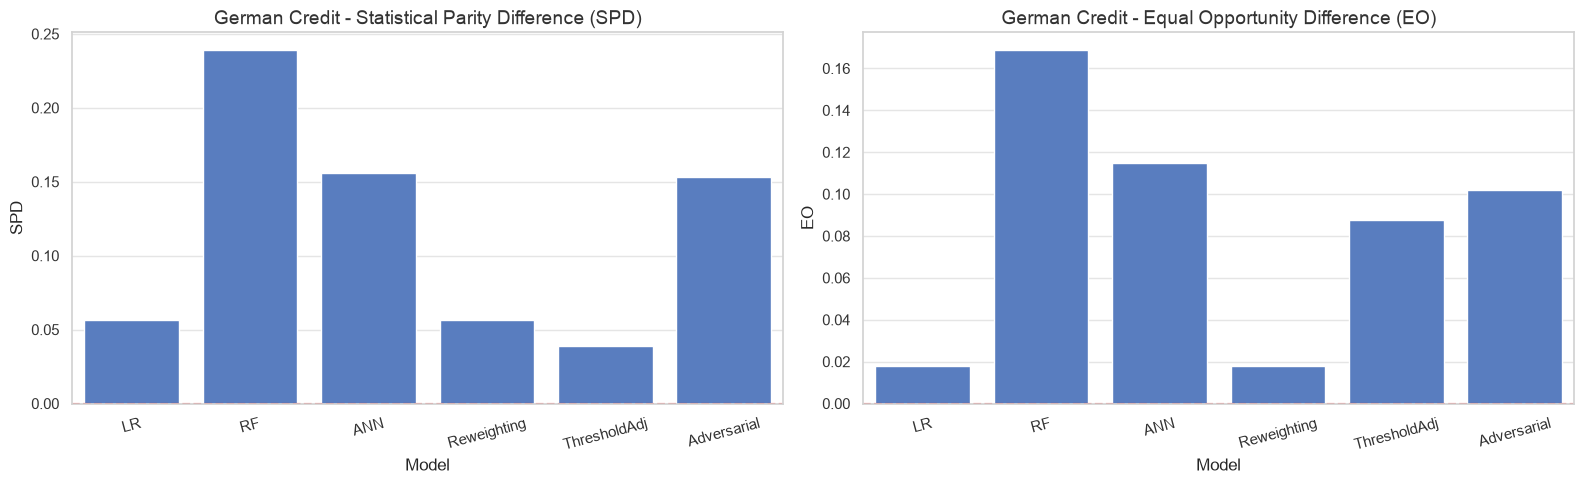

In [6]:
print("\n================ FETCHING GERMAN CREDIT DATASET ================")
url_german = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
cols_german = [f"feature_{i}" for i in range(1, 21)] + ["credit_risk"]
german = pd.read_csv(url_german, sep=' ', names=cols_german, header=None)

# Rename features so SHAP plots generate human-readable axes
german.rename(columns={"feature_13": "age", "feature_1": "checking_account_status"}, inplace=True)

# 1 = Good Credit (Favorable outcome), 2 = Bad Credit (Unfavorable outcome)
german["credit_risk"] = german["credit_risk"].apply(lambda x: 1 if x == 1 else 0)

# Age > 25 is Privileged (1)
prot_german = german["age"].apply(lambda x: 1 if x > 25 else 0)

le_german = LabelEncoder()
for col in german.select_dtypes(include="object").columns:
    german[col] = le_german.fit_transform(german[col])

X_g = german.drop("credit_risk", axis=1)
y_g = german["credit_risk"]

X_train_g, X_test_g, y_train_g, y_test_g, prot_train_g, prot_test_g = train_test_split(
    X_g, y_g, prot_german, stratify=prot_german, test_size=0.2, random_state=42
)

scaler_g = StandardScaler()
X_train_scaled_g = scaler_g.fit_transform(X_train_g)
X_test_scaled_g = scaler_g.transform(X_test_g)

results_german = run_fairness_pipeline(
    X_train_scaled_g, X_test_scaled_g, y_train_g, y_test_g,
    prot_train_g, prot_test_g, X_g.columns, "german", "age"
)
plot_comprehensive_metrics(results_german, "German Credit")


## 5. SHAP Interaction Analysis (Explainability & Indirect Bias)

We compute and plot SHAP interactions to explain how key features interact and potentially introduce indirect bias in Random Forest model predictions.



Computing SHAP Interactions for ADULT...


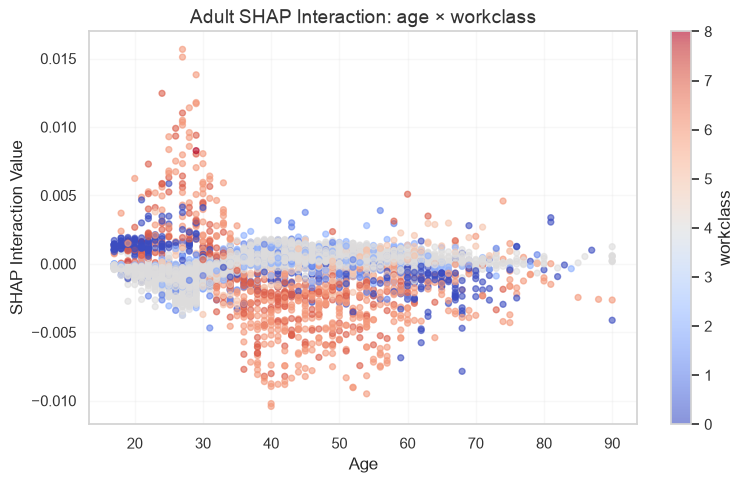


Computing SHAP Interactions for COMPAS...


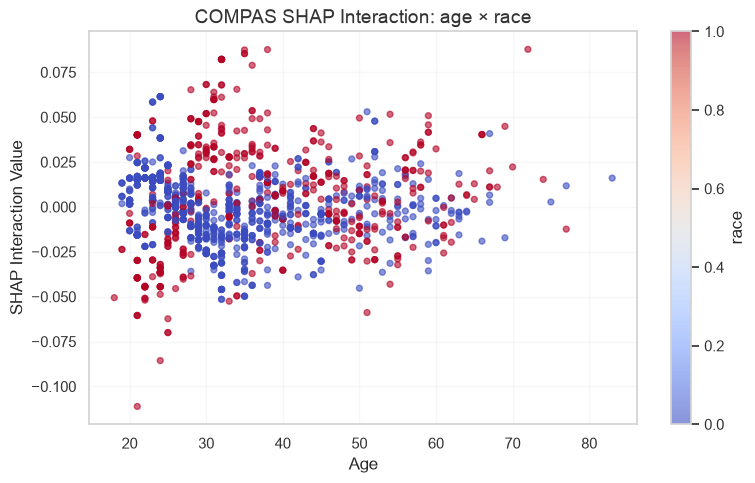


Computing SHAP Interactions for GERMAN_CREDIT...


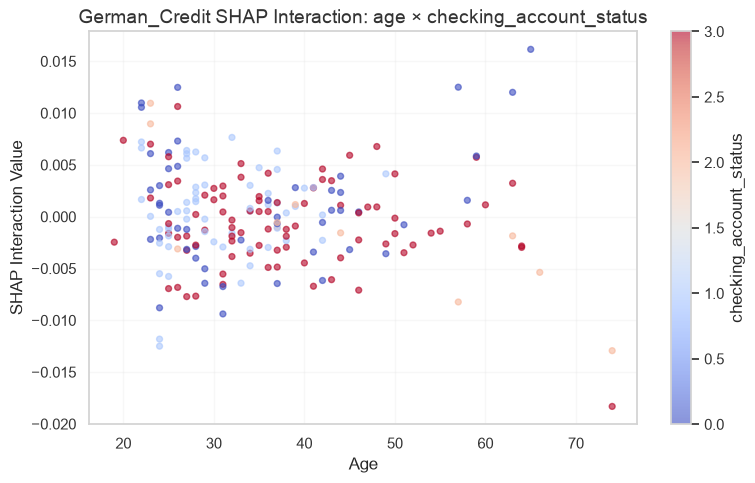

In [7]:
def generate_shap_interactions(X_train, y_train, X_test, feature_names, dataset_name, focus_features):
    """
    Generate SHAP interaction plots.
    """
    print(f"\nComputing SHAP Interactions for {dataset_name.upper()}...")

    rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf_model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(rf_model)
    interaction_values = explainer.shap_interaction_values(X_test)

    if isinstance(interaction_values, list):
        interaction_values = interaction_values[1]
    elif interaction_values.ndim == 4:
        interaction_values = interaction_values[:, :, :, 1]

    idx_0 = feature_names.get_loc(focus_features[0])
    idx_1 = feature_names.get_loc(focus_features[1])

    interaction_effects = interaction_values[:, idx_0, idx_1]

    x_data = X_test.iloc[:, idx_0].to_numpy()
    c_data = X_test.iloc[:, idx_1].to_numpy()
    y_data = np.asarray(interaction_effects).reshape(-1)

    n = min(len(x_data), len(y_data), len(c_data))
    x_data = x_data[:n]; y_data = y_data[:n]; c_data = c_data[:n]

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(x_data, y_data, c=c_data, cmap="coolwarm", alpha=0.6, s=18)
    
    plt.colorbar(scatter, label=focus_features[1])
    plt.xlabel(focus_features[0].replace("_", " ").title())
    plt.ylabel("SHAP Interaction Value")
    plt.title(f"{dataset_name} SHAP Interaction: {focus_features[0]} \u00d7 {focus_features[1]}")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{dataset_name.lower()}_shap_interactions.png", dpi=300)
    plt.show()

# Generate the 3 SHAP plots
adult_feature_names = X_a.columns
generate_shap_interactions(X_train_a, y_train_a, X_test_a, adult_feature_names, "Adult", ["age", "workclass"])

compas_feature_names = X_c.columns
generate_shap_interactions(X_train_c, y_train_c, X_test_c, compas_feature_names, "COMPAS", ["age", "race"])

german_feature_names = X_g.columns
generate_shap_interactions(X_train_g, y_train_g, X_test_g, german_feature_names, "German_Credit", ["age", "checking_account_status"])


## 6. Causal Validation via Feature Ablation

To empirically validate the proxy features identified via SHAP interaction analysis, we perform a feature ablation study. We remove the suspected demographic proxy variables from the training data, retrain the models from scratch, and evaluate the change in accuracy and demographic disparity (Statistical Parity Difference).

If the Statistical Parity Difference decreases significantly while maintaining reasonable accuracy, it empirically confirms that the feature functioned as an active proxy for demographic bias.


In [8]:
def run_ablation_study(X_train, X_test, y_train, y_test, prot_train, prot_test, proxy_col, dataset_name):
    print(f"\n--- Running Ablation Study for {dataset_name.upper()} (Removing Proxy: {proxy_col}) ---")
    
    # Train Random Forest baseline (matching explainability model)
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    spd_base, di_base, eo_base, aod_base = fairness_metrics(y_test, y_pred, prot_test)
    acc_base = accuracy_score(y_test, y_pred)
    
    # Train ablated model
    X_train_ablated = X_train.drop(columns=[proxy_col])
    X_test_ablated = X_test.drop(columns=[proxy_col])
    
    rf_ablated = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf_ablated.fit(X_train_ablated, y_train)
    y_pred_ablated = rf_ablated.predict(X_test_ablated)
    spd_abl, di_abl, eo_abl, aod_abl = fairness_metrics(y_test, y_pred_ablated, prot_test)
    acc_abl = accuracy_score(y_test, y_pred_ablated)
    
    results = pd.DataFrame({
        "Metric": ["Accuracy", "SPD (Parity)", "DI (Impact)", "EO (Opportunity)"],
        "Original": [acc_base, spd_base, di_base, eo_base],
        "Ablated (No Proxy)": [acc_abl, spd_abl, di_abl, eo_abl],
        "Delta": [acc_abl - acc_base, spd_abl - spd_base, di_abl - di_base, eo_abl - eo_base]
    })
    
    print(results.to_string(index=False))
    
    # Save ablation study results to CSV
    results.to_csv(f"{dataset_name.lower()}_ablation_results.csv", index=False)
    return results

print("\n=== CAUSAL VALIDATION ABLATION STUDIES ===")
# Adult Income Dataset (Proxy: workclass)
run_ablation_study(X_train_a, X_test_a, y_train_a, y_test_a, prot_train_a, prot_test_a, "workclass", "Adult")

# COMPAS Recidivism Dataset (Proxy: age)
run_ablation_study(X_train_c, X_test_c, y_train_c, y_test_c, prot_train_c, prot_test_c, "age", "COMPAS")

# Statlog German Credit Dataset (Proxy: checking_account_status)
run_ablation_study(X_train_g, X_test_g, y_train_g, y_test_g, prot_train_g, prot_test_g, "checking_account_status", "German_Credit")



=== CAUSAL VALIDATION ABLATION STUDIES ===

--- Running Ablation Study for ADULT (Removing Proxy: workclass) ---


          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.858283            0.857209 -0.001075
    SPD (Parity)  0.153223            0.155501  0.002278
     DI (Impact)  0.284139            0.285746  0.001607
EO (Opportunity)  0.094962            0.104160  0.009198

--- Running Ablation Study for COMPAS (Removing Proxy: age) ---


          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.652807            0.636868 -0.015939
    SPD (Parity)  0.124380            0.184604  0.060225
     DI (Impact)  0.716045            0.509097 -0.206948
EO (Opportunity)  0.152980            0.194950  0.041970

--- Running Ablation Study for GERMAN_CREDIT (Removing Proxy: checking_account_status) ---
          Metric  Original  Ablated (No Proxy)     Delta
        Accuracy  0.810000            0.785000 -0.025000
    SPD (Parity)  0.217024            0.235543  0.018519
     DI (Impact)  0.759193            0.743907 -0.015286
EO (Opportunity)  0.100410            0.191940  0.091530


,Metric,Original,Ablated (No Proxy),Delta
0,Accuracy,0.810000,0.785000,-0.025000
1,SPD (Parity),0.217024,0.235543,0.018519
2,DI (Impact),0.759193,0.743907,-0.015286
3,EO (Opportunity),0.100410,0.191940,0.091530


In [9]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# --- INTERSECTIONAL FAIRNESS ANALYSIS (Adult Dataset) ---
print("\n--- Preliminary Intersectional Analysis: Race x Gender on Adult Dataset ---")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", 
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", 
           "hours-per-week", "native-country", "income"]
df_adult = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True).dropna()

# We evaluate the intersection of race (White/Non-White) and sex (Male/Female)
df_adult['race_binary'] = df_adult['race'].apply(lambda x: 1 if x == ' White' else 0)
df_adult['sex_binary'] = df_adult['sex'].apply(lambda x: 1 if x == ' Male' else 0)
df_adult['intersectional_group'] = df_adult['race_binary'].astype(str) + "_" + df_adult['sex_binary'].astype(str)
# 1_1: White Male (Privileged)
# 0_0: Non-White Female (Most Unprivileged)

X_inter = df_adult.drop(['income', 'race', 'sex', 'intersectional_group'], axis=1)
X_inter = pd.get_dummies(X_inter, drop_first=True)
y_inter = LabelEncoder().fit_transform(df_adult['income'])
prot_inter = df_adult['intersectional_group']

X_tr_i, X_te_i, y_tr_i, y_te_i, p_tr_i, p_te_i = train_test_split(X_inter, y_inter, prot_inter, test_size=0.3, random_state=42)

rf_inter = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_inter.fit(X_tr_i, y_tr_i)
preds_rf = rf_inter.predict(X_te_i)

print("Evaluating Random Forest on Intersectional Subgroups (Positive Prediction Rates):")
for group in ['1_1', '1_0', '0_1', '0_0']:
    group_mask = (p_te_i == group)
    if np.sum(group_mask) > 0:
        rate = np.mean(preds_rf[group_mask])
        true_rate = np.mean(y_te_i[group_mask])
        print(f"Group {group} -> True Rate: {true_rate:.3f}, Predicted Positive Rate: {rate:.3f}")



--- Preliminary Intersectional Analysis: Race x Gender on Adult Dataset ---


Evaluating Random Forest on Intersectional Subgroups (Positive Prediction Rates):
Group 0_0 -> True Rate: 0.237, Predicted Positive Rate: 0.157
